# Reproducing M2-CL: Multiscale & Multilayer Contrastive Learning for DG
**Paper:** Ballas & Diou, *IEEE Transactions on Artificial Intelligence*, 2024

**Dataset:** PACS (Leave-One-Domain-Out, DomainBed IID-validation protocol)  
**Backbone:** ResNet-18 pretrained on ImageNet  

.

## 1. Setup & Mount Drive

In [ ]:
from google.colab import drive
import zipfile, os

drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/PACS.zip'

if not os.path.exists('/content/PACS_extracted_flag'):
    print('Extracting PACS.zip...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/')
    open('/content/PACS_extracted_flag', 'w').close()
    print('Done.')
else:
    print('Already extracted.')

PACS_ROOT = None
for root, dirs, files in os.walk('/content'):
    if 'art_painting' in dirs and 'cartoon' in dirs:
        PACS_ROOT = root
        break

assert PACS_ROOT is not None, 'PACS root not found — check ZIP structure'
print(f'PACS_ROOT: {PACS_ROOT}')
print('Domains found:', sorted(os.listdir(PACS_ROOT)))


Mounted at /content/drive
Extracting PACS.zip...
Done.
PACS_ROOT: /content/pacs_data/pacs_data
Domains found: ['art_painting', 'cartoon', 'photo', 'sketch']


## 2. Reproducibility Seed
Sets a global random seed for bit-exact reproducibility. The paper reports averages over 3 seeds in DomainBed; this notebook uses seed=0 for a single representative run.

In [ ]:
import random, numpy as np, torch

SEED = 0

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()
print(f'Global seed set to {SEED}')


Global seed set to 0


## 3. Dataset & DataLoaders

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

DOMAINS    = ['art_painting', 'cartoon', 'photo', 'sketch']
BATCH_SIZE = 128  # paper value

TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

TEST_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def get_classes(root):
    d = os.path.join(root, DOMAINS[0])
    return sorted([c for c in os.listdir(d) if os.path.isdir(os.path.join(d, c))])


def build_paths(root, domains, classes):
    data = []
    for dom in domains:
        for idx, cls in enumerate(classes):
            folder = os.path.join(root, dom, cls)
            if not os.path.isdir(folder): continue
            for f in os.listdir(folder):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    data.append((os.path.join(folder, f), idx))
    return data


class PACSDataset(Dataset):
    def __init__(self, samples, train=True):
        self.samples   = samples
        self.transform = TRAIN_TRANSFORM if train else TEST_TRANSFORM
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        path, label = self.samples[i]
        return self.transform(Image.open(path).convert('RGB')), label


def get_loaders(root, test_domain, batch_size=BATCH_SIZE, val_fraction=0.2):
    """
    DomainBed IID-validation protocol.
    Returns: train_loader, val_loader, test_loader, num_classes
    """
    classes    = get_classes(root)
    train_doms = [d for d in DOMAINS if d != test_domain]
    all_src    = build_paths(root, train_doms, classes)

    # Deterministic 80/20 split of source images
    rng     = np.random.RandomState(SEED)
    perm    = rng.permutation(len(all_src))
    cut     = int(len(perm) * (1 - val_fraction))
    tr_data = [all_src[i] for i in perm[:cut]]
    va_data = [all_src[i] for i in perm[cut:]]
    te_data = build_paths(root, [test_domain], classes)

    kw = dict(num_workers=2, pin_memory=True)
    train_loader = DataLoader(PACSDataset(tr_data, train=True),
                              batch_size=batch_size, shuffle=True, drop_last=False, **kw)
    val_loader   = DataLoader(PACSDataset(va_data, train=False),
                              batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(PACSDataset(te_data, train=False),
                              batch_size=batch_size, shuffle=False, **kw)

    print(f'  [{test_domain} held out]  Train:{len(tr_data):,}  '
          f'Val:{len(va_data):,}  Test:{len(te_data):,}  Classes:{len(classes)}')
    return train_loader, val_loader, test_loader, len(classes)


# Sanity check
tr, va, te, nc = get_loaders(PACS_ROOT, 'art_painting')
imgs, lbs = next(iter(tr))
print(f'Batch shape: {imgs.shape}  Label range: [{lbs.min()}, {lbs.max()}]')
print('Dataset module ready ')


  [art_painting held out]  Train:6,354  Val:1,589  Test:2,048  Classes:7
Batch shape: torch.Size([128, 3, 224, 224])  Label range: [0, 6]
Dataset module ready 


## 4. Model Architecture (ERM · M2 · M2-CL)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


# ── ERM Baseline ──────────────────────────────────────────────────────────
class ERM(nn.Module):
    """Standard ResNet-18 fine-tuned with cross-entropy (Section II baseline)."""
    def __init__(self, num_classes):
        super().__init__()
        bb              = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.features   = nn.Sequential(*list(bb.children())[:-1])
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.features(x).flatten(1)), None


# ── Concentration Pipeline (Fig. 4, one branch) ───────────────────────────
class ConcentrationPipeline(nn.Module):
    """
    1x1 Conv -> BN -> ReLU -> Spatial Dropout -> AdaptiveMaxPool -> Flatten -> Linear -> ReLU
    ONE linear layer per pipeline, exactly as drawn in Fig. 4.
    """
    def __init__(self, in_channels, mid_channels, pool_size, mlp_dim=128):
        super().__init__()
        self.conv    = nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False)
        self.bn      = nn.BatchNorm2d(mid_channels)
        self.drop    = nn.Dropout2d(p=0.5)
        self.pool    = nn.AdaptiveMaxPool2d(pool_size)
        self.mlp     = nn.Sequential(
            nn.Flatten(),
            nn.Linear(mid_channels * pool_size * pool_size, mlp_dim),
            nn.ReLU(inplace=True),
        )
        self.out_dim = mlp_dim
    def forward(self, x):
        h = F.relu(self.bn(self.conv(x)), inplace=True)
        return self.mlp(self.pool(self.drop(h)))


# ── Extraction Block (parallel pipelines, Fig. 4) ─────────────────────────
class ExtractionBlock(nn.Module):
    """
    Early layers (layer1, layer2): 3 pipelines, pool sizes 8x8, 4x4, 2x2
    Later layers (layer3, layer4): 2 pipelines, pool sizes 7x7, 3x3
    """
    def __init__(self, in_channels, r=4, pool_sizes=(4, 2), mlp_dim=128):
        super().__init__()
        mid          = max(in_channels // r, 8)
        self.pipes   = nn.ModuleList([
            ConcentrationPipeline(in_channels, mid, ps, mlp_dim)
            for ps in pool_sizes
        ])
        self.out_dim = mlp_dim * len(pool_sizes)
    def forward(self, x):
        return torch.cat([p(x) for p in self.pipes], dim=1)


# ── M2 / M2-CL (Fig. 3, Section III-E) ──────────────────────────────────
class M2(nn.Module):
    """
    layer1 (64ch,  56x56) -> eb1: 3 pipes (8,4,2) -> 384-d
    layer2 (128ch, 28x28) -> eb2: 3 pipes (8,4,2) -> 384-d
    layer3 (256ch, 14x14) -> eb3: 2 pipes (7,3)   -> 256-d
    layer4 (512ch,  7x7)  -> eb4: 2 pipes (7,3)   -> 256-d
    + global avg pool                              -> 512-d
    Total concat: 1792-d -> FC classifier
    """
    def __init__(self, num_classes, use_cl=False, mlp_dim=128):
        super().__init__()
        self.use_cl = use_cl
        bb           = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.layer0  = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1  = bb.layer1
        self.layer2  = bb.layer2
        self.layer3  = bb.layer3
        self.layer4  = bb.layer4
        self.avgpool = bb.avgpool
        self.eb1     = ExtractionBlock(64,  r=4, pool_sizes=(8, 4, 2), mlp_dim=mlp_dim)
        self.eb2     = ExtractionBlock(128, r=4, pool_sizes=(8, 4, 2), mlp_dim=mlp_dim)
        self.eb3     = ExtractionBlock(256, r=4, pool_sizes=(7, 3),    mlp_dim=mlp_dim)
        self.eb4     = ExtractionBlock(512, r=4, pool_sizes=(7, 3),    mlp_dim=mlp_dim)
        total        = self.eb1.out_dim+self.eb2.out_dim+self.eb3.out_dim+self.eb4.out_dim+512
        self.classifier = nn.Linear(total, num_classes)
    def forward(self, x):
        x  = self.layer0(x)
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        e1, e2 = self.eb1(f1), self.eb2(f2)
        e3, e4 = self.eb3(f3), self.eb4(f4)
        gap    = self.avgpool(f4).flatten(1)
        z      = torch.cat([e1, e2, e3, e4, gap], dim=1)
        reps   = [e1, e2, e3, e4] if self.use_cl else None
        return self.classifier(z), reps


# ── Contrastive Loss (Eq. 3-6, Section III-F) ────────────────────────────
def contrastive_loss(reps, labels, tau=1.0):
    """
    For each extraction layer l:
      numerator   = sum_{i,j in same class, i!=j} exp(sim_ij / tau)
      denominator = sum_{ALL i!=j} exp(sim_ij / tau)
      log p^(l)(c) = log(numer_c / denom)  for each class c
      layer loss   = -mean_c log p^(l)(c)   [mean over classes, not sum]
    total loss = mean over layers.

    Normalization note: we take the MEAN over observed classes per layer
    (not the raw sum). This keeps the contrastive loss on the same scale as
    the CE loss regardless of the number of classes present in the batch,
    which stabilizes the effective weight of alpha across different batch.
    """
    total, n_layers = torch.tensor(0.0, device=labels.device), 0
    for u in reps:
        u   = F.normalize(u, dim=1)
        sim = torch.mm(u, u.t()) / tau
        B   = u.size(0)
        # Denominator: all off-diagonal entries (all distinct pairs)
        off   = ~torch.eye(B, dtype=torch.bool, device=labels.device)
        denom = sim[off].exp().sum()
        log_p_list = []
        for c in labels.unique():
            idx = (labels == c).nonzero(as_tuple=True)[0]
            if len(idx) < 2: continue
            pos_sim = sim[idx][:, idx]
            nc_off  = ~torch.eye(len(idx), dtype=torch.bool, device=labels.device)
            numer   = pos_sim[nc_off].exp().sum()
            log_p_list.append(torch.log(numer / (denom)))
        if log_p_list:
            # Mean over classes (not sum) — keeps loss scale stable
            total   += -torch.stack(log_p_list).mean()
            n_layers += 1
    return total / max(n_layers, 1)


# ── Architecture verification & parameter count table ───────────────────
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

print(f"{"Model":<12} {"Total params":>15} {"Trainable":>15} {"Feature dim":>13}")
print("-" * 58)
for _nc in [7]:  # PACS has 7 classes
    for _name, _cls, _kw in [
        ("ERM",   ERM, {}),
        ("M2",    M2,  {"use_cl": False}),
        ("M2-CL", M2,  {"use_cl": True}),
    ]:
        _m   = _cls(_nc, **_kw)
        _tot, _tr = count_params(_m)
        _fd  = getattr(_m, "classifier", None)
        _fd  = _fd.in_features if _fd is not None else "-"
        print(f"{_name:<12} {_tot:>15,} {_tr:>15,} {str(_fd):>13}")
        del _m
print("-" * 58)
print("Feature dim for M2/M2-CL should be 1792 (384+384+256+256+512)")
# Assert correctness
_chk = M2(7, use_cl=True)
assert _chk.classifier.in_features == 1792, f'Dim mismatch: {_chk.classifier.in_features}'
del _chk
torch.cuda.empty_cache()
print("Architecture verified ✓")


Device: cuda
Model           Total params       Trainable   Feature dim
----------------------------------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


ERM               11,180,103      11,180,103           512
M2                13,312,103      13,312,103          1792
M2-CL             13,312,103      13,312,103          1792
----------------------------------------------------------
Feature dim for M2/M2-CL should be 1792 (384+384+256+256+512)
Architecture verified ✓


## 5. Training Loop

| Hyper-parameter | Value | Source |
|---|---|---|
| Optimizer | SGD | Paper Sec IV-B |
| Learning rate | 5e-4 (uniform) | DomainBed default for PACS |
| Momentum | 0.9 | Paper |
| Weight decay | 5e-4 | Paper |
| Scheduler | CosineAnnealingLR, T_max=30, eta_min=0 | Paper |
| Epochs | 30 | Paper |
| alpha (CL weight) | 0.01 | Paper Table III |
| tau (temperature) | 1.0 | Paper |


In [ ]:
import time
# Use the non-deprecated API (torch.amp, not torch.cuda.amp)
from torch.amp import autocast, GradScaler

def evaluate(model, loader):
    """Returns accuracy on a DataLoader."""
    model.eval()
    c, t = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                logits, _ = model(imgs.to(DEVICE))
            c += (logits.argmax(1) == labels.to(DEVICE)).sum().item()
            t += len(labels)
    return 100 * c / t


def train_one(model_name, test_domain, root=PACS_ROOT,
              epochs=30, batch=BATCH_SIZE, lr=5e-4, alpha=0.01, tau=1.0):
    set_seed()
    train_loader, val_loader, test_loader, num_classes = get_loaders(root, test_domain, batch)

    model = (ERM(num_classes) if model_name == "erm"
             else M2(num_classes, use_cl=(model_name == "m2cl")))
    model.to(DEVICE)

    # Single uniform LR — matches paper protocol. No differential LR.
    optimizer = torch.optim.SGD(
        model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce        = nn.CrossEntropyLoss()

    # AMP: ~1.7x speedup on T4, halves VRAM.
    # Using torch.amp (not deprecated torch.cuda.amp).
    use_amp = (DEVICE.type == "cuda")
    scaler  = GradScaler(device=DEVICE.type, enabled=use_amp)

    best_val_acc = 0.0
    best_ckpt    = None
    history      = []

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n=== [{model_name.upper()}] test={test_domain} | params={n_params:,} ===")

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, seen = 0.0, 0, 0
        t0 = time.time()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast(device_type=DEVICE.type, enabled=use_amp):
                logits, reps = model(imgs)
                loss = ce(logits, labels)
                if reps is not None:
                    loss = loss + alpha * contrastive_loss(reps, labels, tau)
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            seen       += len(labels)
        scheduler.step()

        val_acc   = evaluate(model, val_loader)
        test_acc  = evaluate(model, test_loader)  # logged only — NOT used for selection
        train_acc = 100 * correct / seen

        # Model selection by SOURCE-DOMAIN val acc — no test-domain leakage
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_ckpt    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        history.append({"epoch": epoch, "train_acc": train_acc,
                         "val_acc": val_acc, "test_acc": test_acc})
        print(f"  Ep {epoch:02d}/{epochs}  loss={total_loss/seen:.4f}  "
              f"train={train_acc:.1f}%  val={val_acc:.1f}%  test={test_acc:.1f}%  "
              f"({time.time()-t0:.0f}s)")

    # Evaluate the val-selected checkpoint on the test domain
    model.load_state_dict(best_ckpt)
    final_test_acc = evaluate(model.to(DEVICE), test_loader)

    os.makedirs("/content/checkpoints", exist_ok=True)
    ckpt_path = f"/content/checkpoints/{model_name}_{test_domain}.pt"
    torch.save(best_ckpt, ckpt_path)

    print(f"  Best val acc   = {best_val_acc:.2f}%  (IID model selection)")
    print(f"  Final test acc = {final_test_acc:.2f}%  -> {ckpt_path}\n")
    return final_test_acc, history


print("Training function ready ✓")


Training function ready ✓


## 6. Leave-One-Domain-Out Experiments

**Session-safe design:** Each domain fold saves its 3 checkpoints to Drive immediately.
If the session dies mid-run, start a fresh session, re-run cells 1–5 to restore
all definitions, then skip the domains already completed by checking which
checkpoints already exist in Drive. Results are loaded from Drive at the end.


In [ ]:
import json

MODELS     = ["erm", "m2", "m2cl"]
CKPT_DIR   = "/content/checkpoints"
DRIVE_DIR  = "/content/drive/MyDrive/m2cl_checkpoints"
HIST_PATH  = "/content/drive/MyDrive/m2cl_history.json"
os.makedirs(CKPT_DIR,  exist_ok=True)
os.makedirs(DRIVE_DIR, exist_ok=True)

restored = []
for fname in os.listdir(DRIVE_DIR):
    if fname.endswith(".pt"):
        dst = os.path.join(CKPT_DIR, fname)
        if not os.path.exists(dst):
            import shutil
            shutil.copy(os.path.join(DRIVE_DIR, fname), dst)
            restored.append(fname)
if restored:
    print(f"Restored {len(restored)} checkpoints from Drive: {restored}")
else:
    print("No prior checkpoints to restore.")


results  = {m: {} for m in MODELS}
all_hist = {m: {} for m in MODELS}
if os.path.exists(HIST_PATH):
    with open(HIST_PATH) as f:
        saved = json.load(f)
    results  = saved.get("results",  results)
    all_hist = saved.get("all_hist", all_hist)
    done = [(m, d) for m in MODELS for d in DOMAINS if results[m].get(d) is not None]
    print(f"Loaded prior results for {len(done)} completed runs: {done}")


for dom in DOMAINS:
    for m in MODELS:
        if results[m].get(dom) is not None:
            print(f"  Skipping {m}/{dom} — already done ({results[m][dom]:.2f}%)")
            continue
        acc, hist        = train_one(m, dom)
        results[m][dom]  = acc
        all_hist[m][dom] = hist
        # Save checkpoint to Drive immediately after each fold
        src = os.path.join(CKPT_DIR, f"{m}_{dom}.pt")
        dst = os.path.join(DRIVE_DIR, f"{m}_{dom}.pt")
        import shutil
        shutil.copy(src, dst)
        print(f"  Checkpoint saved to Drive: {dst}")
        # Persist results after every completed fold
        with open(HIST_PATH, "w") as f:
            json.dump({"results": results, "all_hist": all_hist}, f)
        print(f"  History saved to Drive: {HIST_PATH}")

print("\nAll available experiments complete.")
completed = [(m, d) for m in MODELS for d in DOMAINS if results[m].get(d) is not None]
print(f"Completed folds: {len(completed)}/12")


Restored 10 checkpoints from Drive: ['m2cl_art_painting.pt', 'erm_sketch.pt', 'erm_art_painting.pt', 'm2_cartoon.pt', 'm2cl_cartoon.pt', 'erm_photo.pt', 'erm_cartoon.pt', 'm2cl_photo.pt', 'm2_art_painting.pt', 'm2_photo.pt']
Loaded prior results for 12 completed runs: [('erm', 'art_painting'), ('erm', 'cartoon'), ('erm', 'photo'), ('erm', 'sketch'), ('m2', 'art_painting'), ('m2', 'cartoon'), ('m2', 'photo'), ('m2', 'sketch'), ('m2cl', 'art_painting'), ('m2cl', 'cartoon'), ('m2cl', 'photo'), ('m2cl', 'sketch')]
  Skipping erm/art_painting — already done (73.14%)
  Skipping m2/art_painting — already done (74.27%)
  Skipping m2cl/art_painting — already done (74.22%)
  Skipping erm/cartoon — already done (70.69%)
  Skipping m2/cartoon — already done (67.36%)
  Skipping m2cl/cartoon — already done (68.30%)
  Skipping erm/photo — already done (94.37%)
  Skipping m2/photo — already done (95.39%)
  Skipping m2cl/photo — already done (95.45%)
  Skipping erm/sketch — already done (66.51%)
  Skip

## 7. Results Table

In [ ]:
import numpy as np

PAPER = {
    'erm' : [79.68, 77.76, 88.91, 75.72],
    'm2'  : [79.86, 77.91, 95.65, 77.90],
    'm2cl': [81.66, 78.42, 97.00, 77.07],
}

dom_labels = ['Art', 'Cartoon', 'Photo', 'Sketch', 'Avg']
col = 12
header = f"{'Model':<14}" + "".join(f"{d:>{col}}" for d in dom_labels)
sep    = "-" * len(header)
print('PACS Leave-One-Domain-Out  |  IID model selection (val acc)')
print(sep); print(header); print(sep)
for m in MODELS:
    our = [results[m].get(d) for d in DOMAINS]
    pap = PAPER[m]
    print(f"{m.upper()+' (ours)':<14}" + "".join(f"{v:>{col}.2f}" for v in our) + f"{np.mean(our):>{col}.2f}")
    print(f"{m.upper()+' (paper)':<14}" + "".join(f"{v:>{col}.2f}" for v in pap) + f"{np.mean(pap):>{col}.2f}")
    print()
print(sep)


PACS Leave-One-Domain-Out  |  IID model selection (val acc)
--------------------------------------------------------------------------
Model                  Art     Cartoon       Photo      Sketch         Avg
--------------------------------------------------------------------------
ERM (ours)           73.14       70.69       94.37       66.51       76.18
ERM (paper)          79.68       77.76       88.91       75.72       80.52

M2 (ours)            74.27       67.36       95.39       61.06       74.52
M2 (paper)           79.86       77.91       95.65       77.90       82.83

M2CL (ours)          74.22       68.30       95.45       61.03       74.75
M2CL (paper)         81.66       78.42       97.00       77.07       83.54

--------------------------------------------------------------------------


## 8. Results Bar Chart

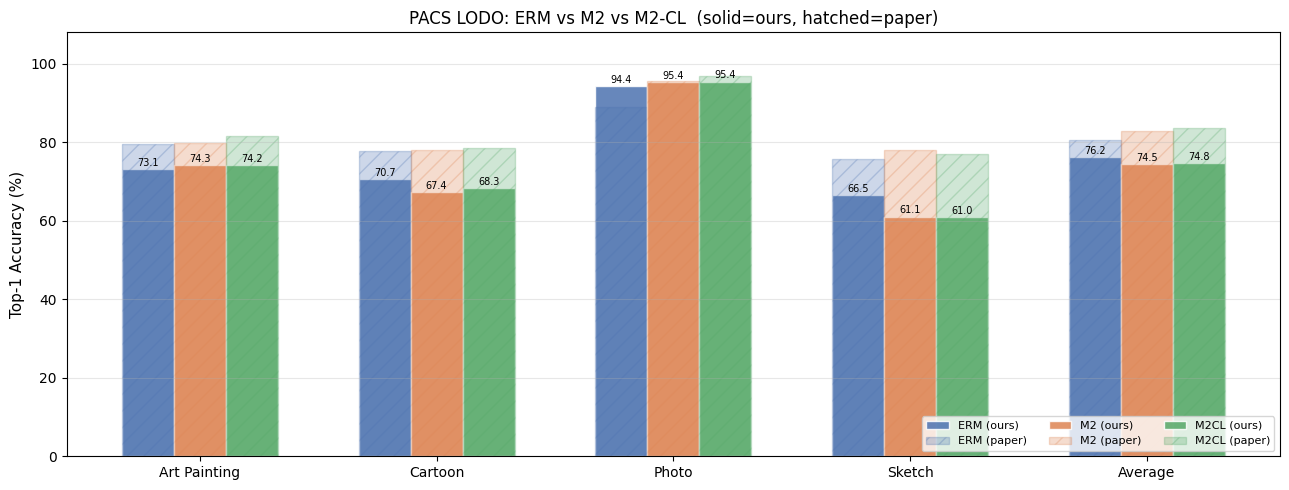

Saved.


In [ ]:
import matplotlib.pyplot as plt

colors  = ['#4C72B0', '#DD8452', '#55A868']
n_m     = len(MODELS)
width   = 0.22
x       = np.arange(len(DOMAINS) + 1)
offsets = np.linspace(-(n_m-1)/2, (n_m-1)/2, n_m) * width

fig, ax = plt.subplots(figsize=(13, 5))
for m, color, offset in zip(MODELS, colors, offsets):
    our = [results[m].get(d, 0) for d in DOMAINS]
    our.append(np.mean(our))
    pap = PAPER[m] + [np.mean(PAPER[m])]
    bars = ax.bar(x + offset, our, width, label=f'{m.upper()} (ours)',
                  color=color, alpha=0.85, edgecolor='white')
    ax.bar(x + offset, pap, width, label=f'{m.upper()} (paper)',
           color=color, alpha=0.28, hatch='//', edgecolor=color)
    for bar, v in zip(bars, our):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([d.replace('_'," ").title() for d in DOMAINS] + ['Average'], fontsize=10)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=11)
ax.set_title('PACS LODO: ERM vs M2 vs M2-CL  (solid=ours, hatched=paper)', fontsize=12)
ax.legend(ncol=3, fontsize=8, loc='lower right')
ax.set_ylim(0, 108); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pacs_results.png', dpi=150)
plt.show(); print('Saved.')


## 9. Training Curves

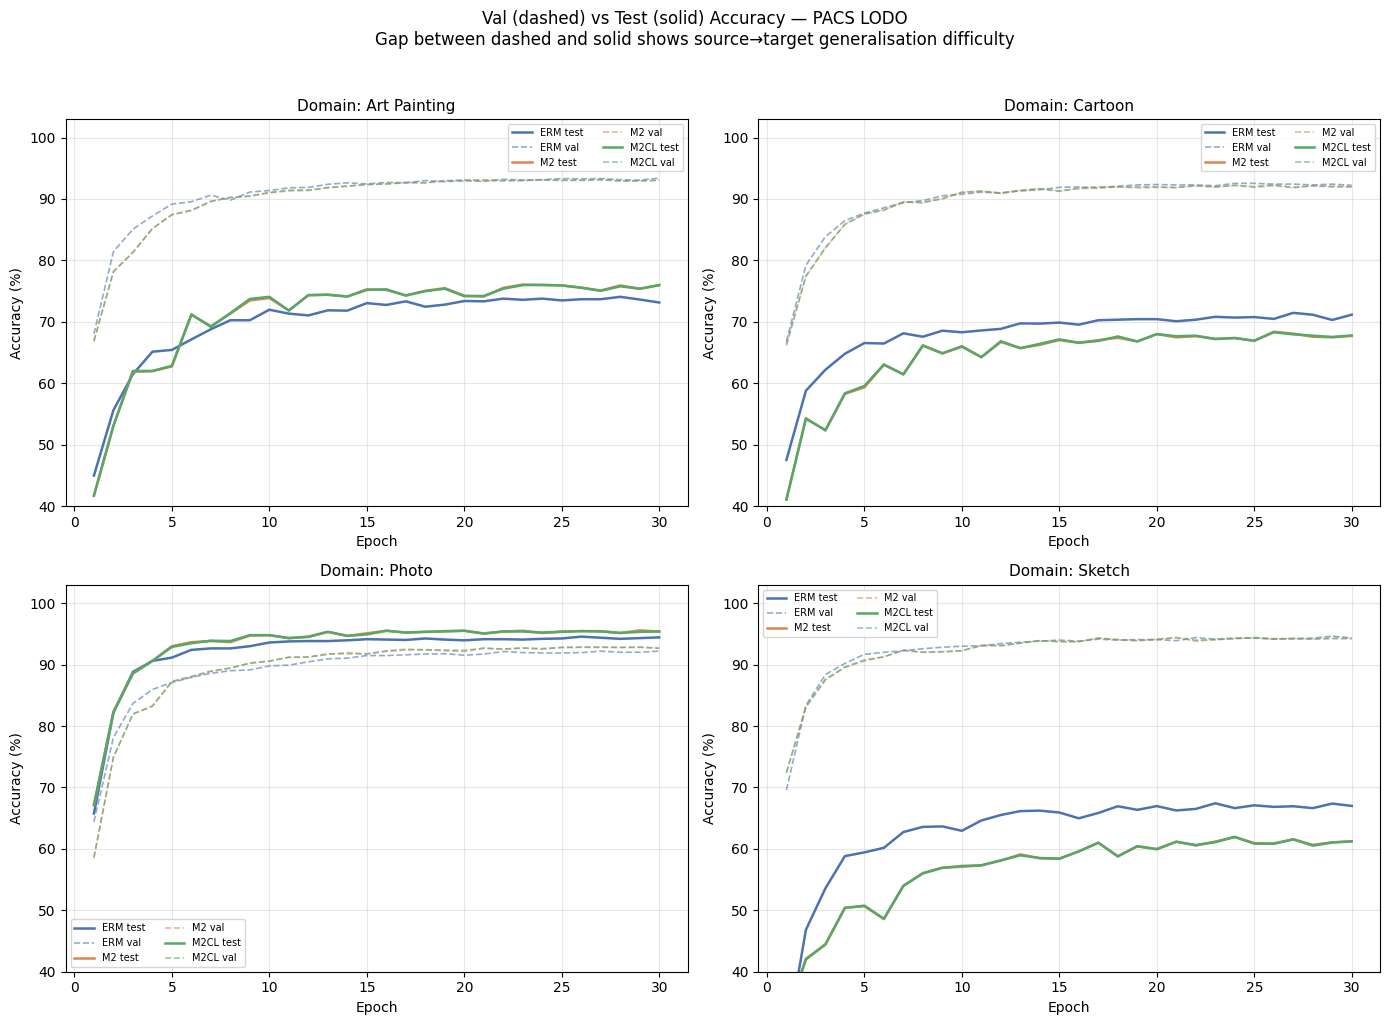

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
cm   = {'erm': '#4C72B0', 'm2': '#DD8452', 'm2cl': '#55A868'}

for ax, dom in zip(axes, DOMAINS):
    for m in MODELS:
        h = all_hist[m].get(dom, [])
        if not h: continue
        epochs = [e['epoch'] for e in h]
        # solid = test (OOD), dashed = val (IID source domains)
        ax.plot(epochs, [e['test_acc'] for e in h],
                color=cm[m], label=f'{m.upper()} test', linewidth=1.8)
        ax.plot(epochs, [e['val_acc'] for e in h],
                color=cm[m], label=f'{m.upper()} val', linewidth=1.2,
                linestyle='--', alpha=0.6)
    ax.set_title(f'Domain: {dom.replace("_"," ").title()}', fontsize=11)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
    ax.set_ylim(40, 103)

fig.suptitle('Val (dashed) vs Test (solid) Accuracy — PACS LODO\n'
             'Gap between dashed and solid shows source→target generalisation difficulty',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Saliency Maps

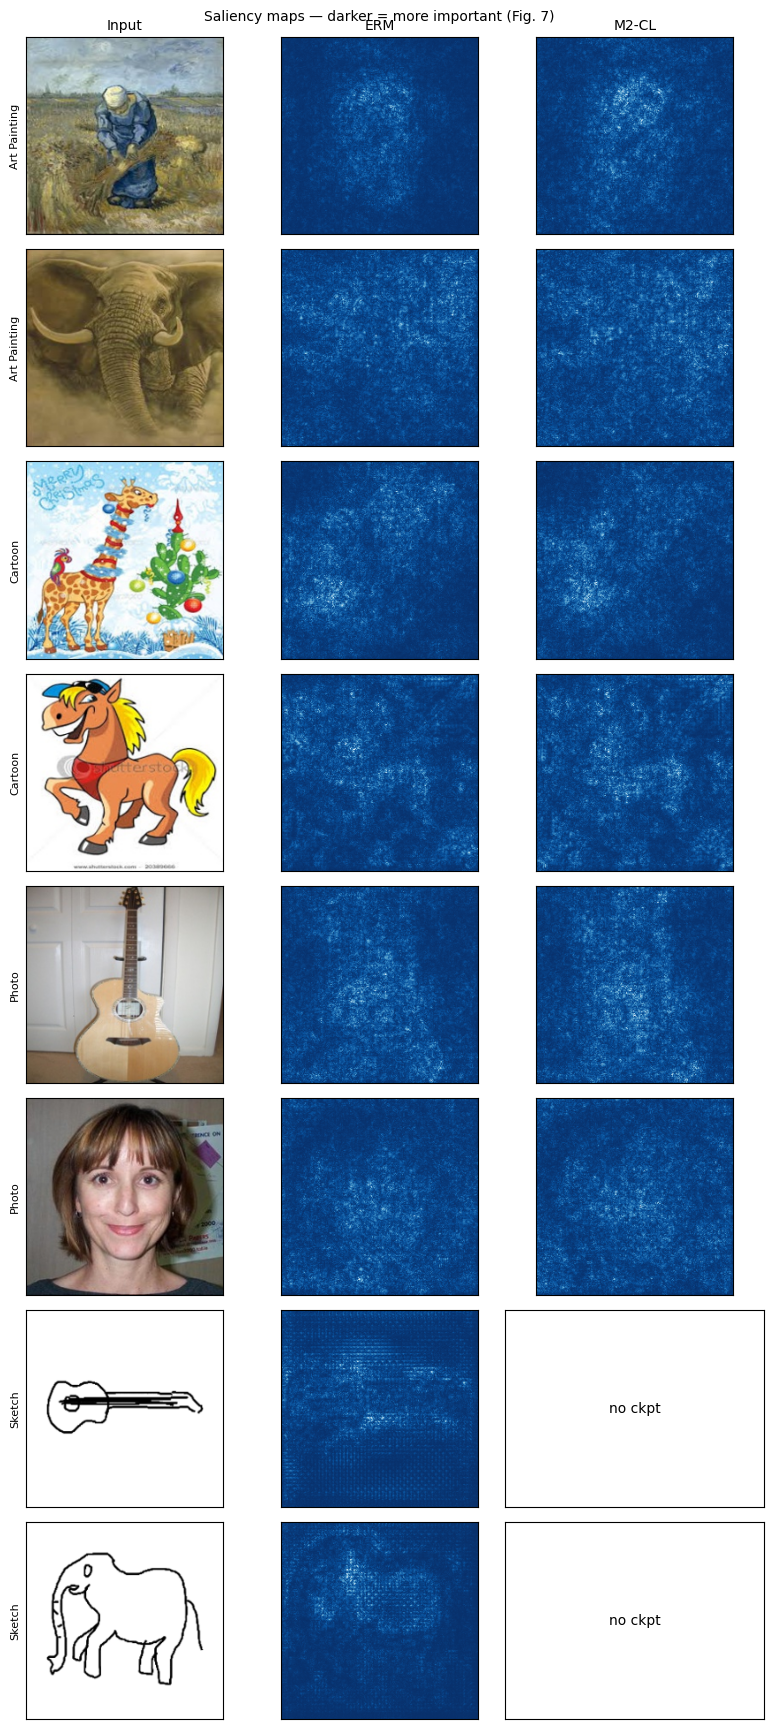

saved.


In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image

MEAN = torch.tensor([0.485, 0.456, 0.406])
STD  = torch.tensor([0.229, 0.224, 0.225])

def denorm(t):
    img = t.cpu().clone()
    for c in range(3):
        img[c] = img[c]*STD[c] + MEAN[c]
    return img.clamp(0,1).permute(1,2,0).numpy()

def saliency(model, tensor):
    model.eval()
    x = tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    logits, _ = model(x)
    logits[0, logits.argmax(1)].backward()
    sal = x.grad.abs().squeeze().max(0).values.cpu().numpy()  # max over channels
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    return sal

def pick_images(root, domains, n=2, seed=7):
    # pick n random test images per domain
    rng, out = random.Random(seed), []
    for dom in domains:
        paths = []
        for cls in os.listdir(os.path.join(root, dom)):
            d = os.path.join(root, dom, cls)
            if not os.path.isdir(d): continue
            paths += [os.path.join(d,f) for f in os.listdir(d)
                      if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for p in rng.sample(paths, min(n, len(paths))):
            pil = Image.open(p).convert('RGB')
            out.append((dom, pil, TEST_TRANSFORM(pil)))
    return out

def load_ckpt(model_name, domain, nc=7):
    path = f'/content/checkpoints/{model_name}_{domain}.pt'
    if not os.path.exists(path):
        path = f'/content/drive/MyDrive/m2cl_checkpoints/{model_name}_{domain}.pt'
    if not os.path.exists(path):
        return None
    m = ERM(nc) if model_name=='erm' else M2(nc, use_cl=(model_name=='m2cl'))
    m.load_state_dict(torch.load(path, map_location='cpu'))
    return m.to(DEVICE).eval()


imgs = pick_images(PACS_ROOT, DOMAINS, n=2)
classes = get_classes(PACS_ROOT)

fig, axes = plt.subplots(len(imgs), 3, figsize=(8, len(imgs)*2.2))
if len(imgs) == 1: axes = axes[None]
axes[0,0].set_title('Input',        fontsize=10)
axes[0,1].set_title('ERM',          fontsize=10)
axes[0,2].set_title('M2-CL',        fontsize=10)

_cache = {}
for i, (dom, pil, t) in enumerate(imgs):
    for name in ('erm', 'm2cl'):
        if (name, dom) not in _cache:
            _cache[(name,dom)] = load_ckpt(name, dom)

    axes[i,0].imshow(pil.resize((224,224)))
    axes[i,0].set_ylabel(dom.replace('_',' ').title(), fontsize=8)

    for col, name in enumerate(['erm','m2cl'], start=1):
        m = _cache[(name, dom)]
        if m is not None:
            axes[i,col].imshow(saliency(m, t), cmap='Blues_r', vmin=0, vmax=1)
        else:
            axes[i,col].text(0.5, 0.5, 'no ckpt', ha='center', va='center',
                             transform=axes[i,col].transAxes)
    for ax in axes[i]: ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Saliency maps — darker = more important (Fig. 7)', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/saliency.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')


## 11. Save All Checkpoints to Drive

In [ ]:
import shutil
save_dir = '/content/drive/MyDrive/m2cl_checkpoints'
os.makedirs(save_dir, exist_ok=True)
shutil.copytree('/content/checkpoints', save_dir, dirs_exist_ok=True)
print(f'All checkpoints saved to {save_dir}')
